<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
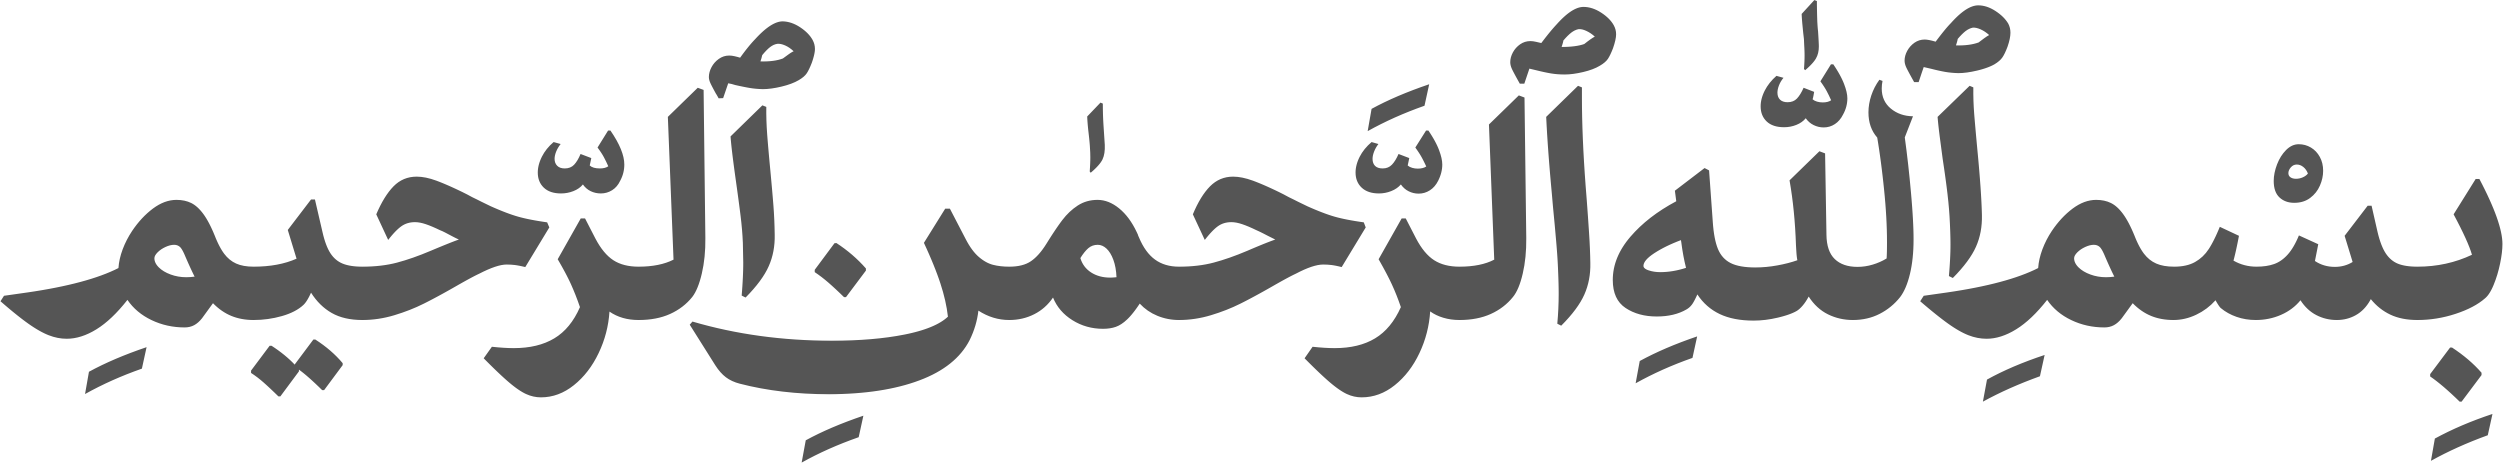
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
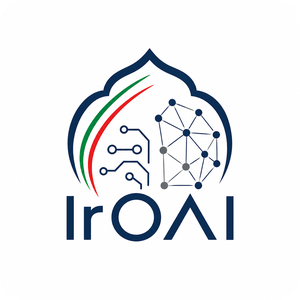
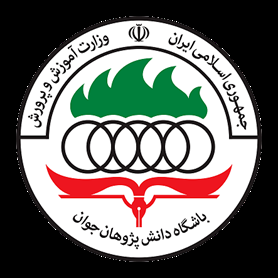
</div>
</div>
<h1 style="text-align: right;">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right;">ماشین بردار پشتیبان (SVM)</h2>
<p style="text-align: right;"><b>مدت پیشنهادی:</b> ۳ ساعت</p>
<p style="text-align: right;"><b>موضوع:</b> یادگیری بانظارت — کلاس‌بندی با مرزِ بیشینه‌ی حاشیه (Max-Margin)</p>
<p style="text-align: right;">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">مقدمه</h2><p style="text-align: right;">ماشین بردار پشتیبان (Support Vector Machine) یکی از کلاسیک‌ترین الگوریتم‌های یادگیری بانظارت است؛ هم به این دلیل که شهود هندسی زیبایی دارد و هم به این دلیل که پایه‌ی روش‌های کرنلی (Kernel Methods) است. در این تمرین اول مفاهیم اصلی را مرور می‌کنیم، بعد با <code dir="ltr">scikit-learn</code> آن‌ها را روی داده‌های ساختگی می‌بینیم، هایپرپارامترها را تغییر می‌دهیم و مرز تصمیم‌ها را مقایسه می‌کنیم، صورت دوگان را بررسی می‌کنیم و در پایان با کرنل‌های معروف آشنا می‌شویم.</p><h3 style="text-align: right;">یادآوری: کلاس‌بندی دودویی با یک ابرصفحه</h3><p style="text-align: right;">فرض کنید داده‌های ما بردارهایی در $\mathbb{R}^p$ هستند و برچسب هر نمونه $y_i \in \{+1, -1\}$ است. یک کلاس‌بند خطی یک ابرصفحه‌ی جداساز تعریف می‌کند:</p>
$$
w^T x + b = 0
$$
<p style="text-align: right;">و برچسب هر نقطه را با علامت مقدار آن روی این ابرصفحه پیش‌بینی می‌کند:</p>
$$
\hat{y} = \operatorname{sign}(w^T x + b)
$$
<h3 style="text-align: right;">فاصله‌ی نقطه تا ابرصفحه</h3><p style="text-align: right;">فاصله‌ی یک نقطه مانند $x_i$ تا این ابرصفحه برابر است با:</p>
$$
d_i = \frac{|w^T x_i + b|}{\|w\|}
$$
<h3 style="text-align: right;">حاشیه (Margin)</h3><p style="text-align: right;">می‌توان مقیاس $w$ و $b$ را طوری گرفت که نزدیک‌ترین نقاطِ هر کلاس روی $|w^T x + b| = 1$ قرار بگیرند. به این ترتیب دو خط موازی $f(x) = +1$ و $f(x) = -1$، «حاشیه‌ی جداسازی» را مشخص می‌کنند و عرض آن برابر است با:</p>
$$
\text{margin} = \frac{2}{\|w\|}
$$
<p style="text-align: right;">پس بیشینه کردن حاشیه معادل کمینه کردن $\frac{1}{2}\|w\|^2$ است.</p><h3 style="text-align: right;">بردارهای پشتیبان</h3><p style="text-align: right;">نقاطی که دقیقاً روی لبه‌های حاشیه قرار دارند، <b>بردار پشتیبان</b> (Support Vector) نامیده می‌شوند. این نقاط تنها نقطه‌هایی هستند که جهت و موقعیت ابرصفحه را تعیین می‌کنند؛ بقیه‌ی داده‌ها بعد از آموزش هیچ نقشی ندارند.</p><h3 style="text-align: right;">داده‌ی غیرقابل‌جداسازی و حاشیه‌ی نرم</h3><p style="text-align: right;">در عمل داده‌ها معمولاً همپوشانی دارند و جداسازی کاملِ آن‌ها ممکن نیست. برای این کار به هر نقطه یک متغیر لغزش $\xi_i \ge 0$ می‌دهیم و مسئله‌ی بهینه‌سازی اولیه (primal) به این شکل در می‌آید:</p>
$$
\min_{w,b,\xi} \ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i \qquad \text{s.t.} \quad y_i(w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$
<p style="text-align: right;">پارامتر $C$ همین تعادل را تنظیم می‌کند: $C$ کوچک یعنی حاشیه‌ی بازتر و خطای بیشتر روی داده‌ی آموزش؛ $C$ بزرگ یعنی حاشیه‌ی باریک‌تر و تلاش برای نداشتن خطای آموزشی.</p><h3 style="text-align: right;">نقشه‌ی این تمرین</h3><ul style="text-align: right;"><li style="text-align: right;"><b>فاز ۱</b> — مرز تصمیم، حاشیه و بردارهای پشتیبان را روی کد می‌بینیم.</li><li style="text-align: right;"><b>فاز ۲</b> — پارامتر $C$ و تعادل بین حاشیه و خطا را با تغییر هایپرپارامتر مقایسه می‌کنیم.</li><li style="text-align: right;"><b>فاز ۳</b> — صورت دوگان (dual) را روی همان مسئله‌ها بررسی می‌کنیم.</li><li style="text-align: right;"><b>فاز ۴</b> — با کرنل‌ها آشنا می‌شویم و چند کرنل معروف را با هم مقایسه می‌کنیم.</li><li style="text-align: right;"><b>فاز ارزیابی</b> — نتیجه‌ی کار خودتان را با مقدار مرجع مقایسه می‌کنید.</li></ul><p style="text-align: right;">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه‌ی کار خودتان است.</p></div>

In [ ]:
# Setup - read-only cell; do not edit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

%matplotlib inline

SEED = 42            # one seed everywhere -> reproducible results
np.random.seed(SEED)


def plot_svm(clf, X, y, title="", ax=None):
    """Draw the decision boundary (solid line), the margin lines (dashed,
    f = +-1), the training points, and the support vectors (ringed)."""
    if ax is None:
        ax = plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=40, zorder=2)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=("#cfe2f3", "#f4cccc"), alpha=0.6)
    ax.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0],
               colors=("k", "k", "k"), linestyles=("--", "-", "--"), linewidths=1.6)
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=150, facecolors="none", edgecolors="k", linewidths=2.0, zorder=3)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    return ax

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۱ — مرز تصمیم، حاشیه و بردارهای پشتیبان روی کد</h2><h3 style="text-align: right;">پیش‌زمینه</h3><p style="text-align: right;">با <code dir="ltr">scikit-learn</code> برازش یک SVM خطی فقط یک خط کد است: <code dir="ltr">SVC(kernel="linear")</code>. بعد از برازش می‌توانیم اجزای مدل را بخوانیم:</p><ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">clf.coef_</code> — همان بردار $w$ (برای کرنل خطی).</li><li style="text-align: right;"><code dir="ltr">clf.intercept_</code> — همان $b$.</li><li style="text-align: right;"><code dir="ltr">clf.support_vectors_</code> — مختصات بردارهای پشتیبان.</li><li style="text-align: right;"><code dir="ltr">clf.dual_coef_</code> — ضرایب دوگان (در فاز ۳ به کار می‌آید).</li></ul><p style="text-align: right;">در سلول دموی زیر (فقط-خواندنی)، یک SVM خطی روی یک داده‌ی ساختگی و کاملاً جداشدنی برازش شده است. به نمودار نگاه کنید: خط توپُر، مرز تصمیم $f(x)=0$ است؛ خطوط چین، لبه‌های حاشیه $f(x)=\pm 1$ هستند و نقطه‌های حلقوی، بردارهای پشتیبان‌اند.</p><h3 style="text-align: right;">کارها</h3><ul style="text-align: right;"><li style="text-align: right;">تابع <code dir="ltr">compute_margin(clf)</code> را بنویسید که با استفاده از <code dir="ltr">clf.coef_</code> عرض حاشیه یعنی $\frac{2}{\|w\|}$ را برمی‌گرداند و آن را برای <code dir="ltr">clf_linear</code> چاپ کنید.</li><li style="text-align: right;">تعداد بردارهای پشتیبان را چاپ کنید و با بررسی مقدار تابع تصمیم روی آن‌ها، تأیید کنید که تقریباً روی $f(x)=\pm 1$ نشسته‌اند.</li></ul><details style="text-align: right;"><summary style="text-align: right;">برای دیدن راهنمایی کلیک کنید</summary><p style="text-align: right;">عرض حاشیه از روی بردار وزن به دست می‌آید: <code dir="ltr">2.0 / np.linalg.norm(clf.coef_)</code>. و برای بررسی بردارهای پشتیبان: <code dir="ltr">np.abs(clf.decision_function(clf.support_vectors_))</code>.</p></details></div>

w (coef_)    : [ 0.30332858 -0.21018456]
b (intercept): 0.7915560377592402
n support vectors: 3


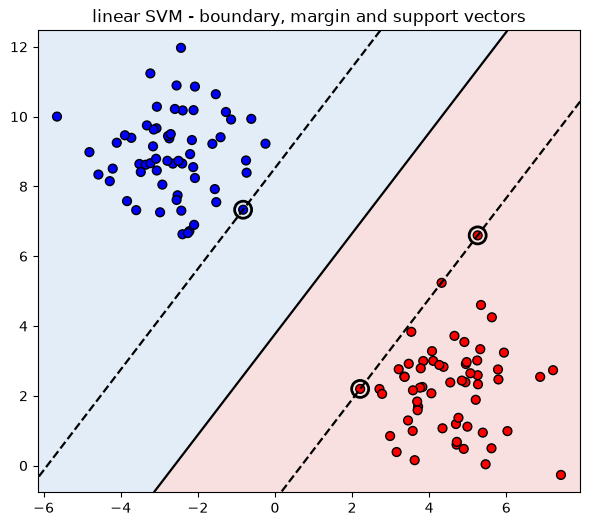

In [ ]:
# Demo - read-only. Fit a linear SVM on a small separable dataset and inspect it.
X_sep, y_sep = make_blobs(n_samples=120, centers=2, cluster_std=1.2, random_state=SEED)

clf_linear = SVC(kernel="linear", C=1.0).fit(X_sep, y_sep)
print("w (coef_)    :", clf_linear.coef_.ravel())
print("b (intercept):", clf_linear.intercept_[0])
print("n support vectors:", len(clf_linear.support_vectors_))

plt.figure(figsize=(7, 6))
plot_svm(clf_linear, X_sep, y_sep, title="linear SVM - boundary, margin and support vectors")
plt.show()

In [ ]:
# TODO: implement compute_margin(clf) that returns the margin width = 2/||w||
#       using clf.coef_ (w) and np.linalg.norm
def compute_margin(clf):
    pass

# TODO: print the margin width of clf_linear
# TODO: print the number of support vectors of clf_linear
# TODO: verify the margin property: |f(x)| of every support vector is ~1
#       (use np.abs(clf_linear.decision_function(clf_linear.support_vectors_)))

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">کدام نقاط به بردار پشتیبان تبدیل شدند و چرا؟ اگر یکی از نقطه‌های غیرپشتیبان را حذف کنیم، مرز تصمیم تغییر می‌کند؟ اگر یک بردار پشتیبان را حذف کنیم چه؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">پاسخ خود را اینجا بنویسید.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۲ — حاشیه‌ی نرم و پارامتر C</h2><p style="text-align: right;">در داده‌ی واقعی، جداسازی کاملِ دو کلاس معمولاً ممکن نیست. SVM با متغیرهای لغزش و پارامتر $C$ یک «حاشیه‌ی نرم» می‌سازد:</p><ul style="text-align: right;"><li style="text-align: right;"><b>$C$ کوچک</b> — جریمه‌ی خطا کم است؛ الگوریتم حاشیه‌ی بازتری انتخاب می‌کند، نمونه‌های بیشتری داخل حاشیه می‌افتند و معمولاً بردارهای پشتیبان بیشتری داریم.</li><li style="text-align: right;"><b>$C$ بزرگ</b> — جریمه‌ی خطا زیاد است؛ الگوریتم حاشیه را باریک می‌کند تا اشتباه‌ها روی داده‌ی آموزش کم شوند و ممکن است بیش‌برازش رخ دهد.</li></ul><p style="text-align: right;">برای دیدن این تعادل با چشم خودتان، یک داده‌ی ساختگی با همپوشانی زیاد می‌سازیم و یک SVM خطی را با سه مقدار مختلف $C$ برازش می‌کنیم:</p><ul style="text-align: right;"><li style="text-align: right;">با <code dir="ltr">make_blobs(n_samples=200, centers=2, cluster_std=3.0, random_state=SEED)</code> داده‌ی همپوشان <code dir="ltr">X_ovl, y_ovl</code> را بسازید.</li><li style="text-align: right;">برای هر $C \in \{0.01, 1, 100\}$ یک <code dir="ltr">SVC(kernel="linear", C=C)</code> برازش کنید، مرز تصمیم‌ها را کنار هم رسم کنید و دقت آموزش و تعداد بردارهای پشتیبان را گزارش دهید.</li></ul><details style="text-align: right;"><summary style="text-align: right;">برای دیدن راهنمایی کلیک کنید</summary><p style="text-align: right;">برای رسم سه نمودار کنار هم می‌توانید از <code dir="ltr">plt.subplots(1, 3, figsize=(15, 4.5))</code> و تابع آماده‌ی <code dir="ltr">plot_svm</code> استفاده کنید.</p></details></div>

In [ ]:
# TODO: generate the overlapping dataset with make_blobs(n_samples=200, centers=2,
#       cluster_std=3.0, random_state=SEED) -> X_ovl, y_ovl
# TODO: for C in [0.01, 1.0, 100.0]:
#       - fit SVC(kernel="linear", C=C) on X_ovl/y_ovl
#       - record the train accuracy and the number of support vectors
# TODO: plot the three decision boundaries side by side (plt.subplots(1, 3))
#       with plot_svm; put C, accuracy and #SV into each title
# TODO: print a small table of (C, train accuracy, n_support_vectors)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">با بزرگ شدن $C$ تعداد بردارهای پشتیبان چه تغییری می‌کند و چرا؟ برای این داده‌ی همپوشان، کدام $C$ مرز «معقول‌تری» می‌دهد و چرا؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">پاسخ خود را اینجا بنویسید.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۳ — صورت دوگان (Dual Form) روی همین مسئله‌ها</h2><h3 style="text-align: right;">چرا دوگان؟</h3><p style="text-align: right;">مسئله‌ی اولیه (primal) یک مسئله‌ی بهینه‌سازی محدب است. با روش ضریب‌های لاگرانژ می‌توان همان مسئله را به صورت «دوگان» با متغیرهای $\alpha_i \ge 0$ نوشت. در جواب بهینه، بردار وزن ترکیبی از نقاط آموزش است:</p>
$$
w = \sum_{i=1}^{n} \alpha_i\, y_i\, x_i
$$
<p style="text-align: right;">و تابع تصمیم (با کرنل) فقط به ضرب داخلی با نقاط آموزش بستگی دارد:</p>
$$
f(x) = \sum_{i=1}^{n} \alpha_i\, y_i\, K(x_i, x) + b
$$
<h3 style="text-align: right;">نکته‌ی کلیدی — شرط KKT</h3><p style="text-align: right;">از شرط مکمل (Complementary Slackness) در KKT نتیجه می‌شود که برای نقطه‌هایی که خارج از حاشیه قرار دارند $\alpha_i = 0$ است و فقط بردارهای پشتیبان $\alpha_i > 0$ دارند. یعنی بعد از آموزش، عملاً فقط بردارهای پشتیبان در پیش‌بینی شرکت می‌کنند.</p><p style="text-align: right;">در <code dir="ltr">scikit-learn</code> این‌ها را به صورت جداگانه می‌بینیم: <code dir="ltr">clf.dual_coef_</code> دقیقاً همان $\alpha_i y_i$ (به تعداد بردارهای پشتیبان) و <code dir="ltr">clf.support_vectors_</code> مختصات همان بردارهاست. برای کرنل خطی باید با جمعِ $\alpha_i y_i x_i$ بتوانیم دوباره به <code dir="ltr">clf.coef_</code> برسیم.</p><h3 style="text-align: right;">کارها (روی همان مسئله‌های فاز ۱ و ۲)</h3><ul style="text-align: right;"><li style="text-align: right;">تابع <code dir="ltr">recover_weights(clf)</code> را بنویسید که $w$ را از <code dir="ltr">dual_coef_</code> و <code dir="ltr">support_vectors_</code> بازسازی کند و آن را با <code dir="ltr">clf_linear.coef_</code> مقایسه کنید.</li><li style="text-align: right;">برای داده‌ی همپوشان، تعداد بردارهای پشتیبان را بر حسب $C \in \{0.01, 0.1, 1, 10, 100\}$ به دست آورید و نمودار آن را رسم کنید.</li></ul><details style="text-align: right;"><summary style="text-align: right;">برای دیدن راهنمایی کلیک کنید</summary><p style="text-align: right;"><code dir="ltr">w = (clf.dual_coef_ @ clf.support_vectors_).ravel()</code> — چون <code dir="ltr">dual_coef_</code> همان $\alpha_i y_i$ است، این جمعِ $\sum \alpha_i y_i x_i$ می‌شود.</p></details></div>

In [ ]:
# TODO: implement recover_weights(clf):
#       w = (clf.dual_coef_ @ clf.support_vectors_).ravel()
#       (dual_coef_ holds alpha_i * y_i, so this equals sum(alpha_i y_i x_i))
def recover_weights(clf):
    pass

# TODO: compare recover_weights(clf_linear) with clf_linear.coef_.ravel()
#       and print both (they should match up to floating-point noise)
# TODO: for C in [0.01, 0.1, 1.0, 10.0, 100.0]: fit a linear SVC on the
#       overlapping data and collect the number of support vectors
# TODO: plot number of support vectors vs C (use plt.xscale("log"))

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">چرا $C$ کوچک‌تر بردارهای پشتیبان بیشتری تولید می‌کند؟ این بردارهای اضافی (که داخل حاشیه افتاده‌اند) چه چیزی را نمایندگی می‌کنند و به ضریب $\alpha$ آن‌ها چه ارتباطی دارد؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">پاسخ خود را اینجا بنویسید.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۴ — کرنل‌ها</h2><h3 style="text-align: right;">ایده</h3><p style="text-align: right;">بعضی داده‌ها در فضای ورودی به صورت خطی جدانشدنی‌اند. ترفند کرنل این است که ویژگی‌ها را به فضای بالاتری ببریم: $\phi(x)$؛ در آن فضا شاید جداشدنی خطی شوند. اما لازم نیست $\phi$ را صریحاً محاسبه کنیم — کافی است ضرب داخلی را بلد باشیم:</p>
$$
K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle
$$
<p style="text-align: right;">و تابع تصمیم به همین شکل در می‌آید:</p>
$$
f(x) = \sum_{i} \alpha_i\, y_i\, K(x_i, x) + b
$$
<h3 style="text-align: right;">چند کرنل معروف</h3>
$$
K_{linear}(x, x') = x^T x'
$$

$$
K_{poly}(x, x') = (\gamma\, x^T x' + r)^d
$$

$$
K_{rbf}(x, x') = \exp\big(-\gamma\, \|x - x'\|^2\big)
$$

$$
K_{sigmoid}(x, x') = \tanh(\gamma\, x^T x' + r)
$$
<p style="text-align: right;">در <code dir="ltr">scikit-learn</code> این‌ها با <code dir="ltr">kernel="linear"</code>، <code dir="ltr">"poly"</code>، <code dir="ltr">"rbf"</code> و <code dir="ltr">"sigmoid"</code> انتخاب می‌شوند (پارامترهای <code dir="ltr">degree</code>، <code dir="ltr">gamma</code> و <code dir="ltr">coef0</code> هم در دسترس‌اند).</p><h3 style="text-align: right;">کارها</h3><ul style="text-align: right;"><li style="text-align: right;">با <code dir="ltr">make_circles(n_samples=300, factor=0.5, noise=0.15, random_state=SEED)</code> داده‌ی غیرخطی <code dir="ltr">X_cir, y_cir</code> را بسازید.</li><li style="text-align: right;">برای هر چهار کرنل یک <code dir="ltr">SVC(kernel=...)</code> برازش کنید، مرزهای تصمیم را در یک شبکه‌ی ۲×۲ رسم کنید و دقت آموزش و تعداد بردارهای پشتیبان را چاپ کنید.</li></ul><details style="text-align: right;"><summary style="text-align: right;">برای دیدن راهنمایی کلیک کنید</summary><p style="text-align: right;">پارامترهای کرنل را پیش‌فرض بگذارید؛ <code dir="ltr">gamma</code> به صورت پیش‌فرض برابر <code dir="ltr">"scale"</code> است. برای نمودار هم کافی است از <code dir="ltr">plot_svm</code> روی هر چهار زیرنمودار استفاده کنید.</p></details></div>

In [ ]:
# TODO: generate the non-linear dataset:
#       X_cir, y_cir = make_circles(n_samples=300, factor=0.5, noise=0.15, random_state=SEED)
# TODO: for each kernel in ["linear", "poly", "rbf", "sigmoid"]:
#       - fit SVC(kernel=k) on X_cir/y_cir
#       - record the train accuracy and the number of support vectors
# TODO: plot the four decision boundaries in a 2x2 grid with plot_svm
# TODO: print (kernel, train accuracy, n_support_vectors)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">اختیاری — نقش γ (گاما) در کرنل RBF</h2><p style="text-align: right;">در کرنل RBF یعنی $K(x, x') = \exp(-\gamma\, \|x - x'\|^2)$، پارامتر $\gamma$ تعیین می‌کند هر نقطه‌ی آموزش تا چه فاصله‌ای بر اطرافش اثر می‌گذارد:</p><ul style="text-align: right;"><li style="text-align: right;"><b>$\gamma$ کوچک</b> — هر نقطه روی ناحیه‌ی بزرگی اثر می‌گذارد؛ مرز تصمیم ساده و نرم می‌شود و ممکن است کم‌برازش (Underfitting) رخ دهد.</li><li style="text-align: right;"><b>$\gamma$ بزرگ</b> — هر نقطه فقط روی همسایه‌های خیلی نزدیکش اثر می‌گذارد؛ مرز دور تک‌تک نقاط می‌پیچد و ممکن است بیش‌برازش (Overfitting) رخ دهد.</li></ul><p style="text-align: right;">در <code dir="ltr">scikit-learn</code> مقدار پیش‌فرض <code dir="ltr">gamma="scale"</code> است که تقریباً برابر $\frac{1}{d \cdot \mathrm{Var}(X)}$ انتخاب می‌شود. حالا با مقادیر مختلف $\gamma$ برازش می‌کنیم و می‌بینیم مرز تصمیم و دقت آموزش/تست چگونه تغییر می‌کند.</p></div>

In [ ]:
# TODO (optional): RBF gamma sweep to see overfitting.
# for g in [0.01, 0.1, 1.0, 10.0, 100.0]:
#     fit SVC(kernel="rbf", gamma=g) on a train/test split of X_cir/y_cir
#     and plot the boundary; a very large gamma hugs the training points
#     (train acc -> 1, test acc drops) -> overfitting

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">چرا کرنل خطی روی داده‌ی دایره‌ای شکست می‌خورد؟ کدام کرنل تمیزترین مرز را ساخت؟ اگر $\gamma$ را خیلی بزرگ کنیم چه می‌شود و چرا به آن بیش‌برازش می‌گوییم؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">پاسخ خود را اینجا بنویسید.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ارزیابی — نتیجه‌ی کار خودتان را ببینید</h2><p style="text-align: right;">سلول زیر یک SVM با کرنل RBF را با پارامترهای <code dir="ltr">C=1.0</code> و <code dir="ltr">gamma=0.5</code> روی داده‌ی دایره‌ای برازش می‌کند و دقتش را روی یک بخش جداگانه‌ی تست (۸۰/۲۰) چاپ می‌کند.</p><p style="text-align: right;">مقدار مورد انتظار راه‌حل مرجع: <b dir="ltr">≈ 0.9500</b></p><p style="text-align: right;">خروجی سلول مرجع زیر (که اجرا نمی‌کنید) مقدار طراح را نشان می‌دهد؛ نتیجه‌ی خودتان را با آن مقایسه کنید. چون seed ثابت است و همین داده‌ی ساختگی استفاده می‌شود، انتظار داریم نتیجه دقیقاً یکسان باشد.</p></div>

In [ ]:
# Evaluation cell - run it and compare with the reference value.
X_ev, y_ev = make_circles(n_samples=300, factor=0.5, noise=0.15, random_state=SEED)
X_ev_tr, X_ev_te, y_ev_tr, y_ev_te = train_test_split(X_ev, y_ev, test_size=0.2, random_state=SEED)
clf_ev = SVC(kernel="rbf", C=1.0, gamma=0.5).fit(X_ev_tr, y_ev_tr)
acc_ev = accuracy_score(y_ev_te, clf_ev.predict(X_ev_te))
print(f"test accuracy (rbf, C=1.0, gamma=0.5): {acc_ev:.4f}")

In [ ]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer reference value (SEED=42, make_circles 300 samples, noise=0.15, 80/20 split):
#   test accuracy (rbf, C=1.0, gamma=0.5): ~0.9500
# Student output should match this exactly (same seed, same data and split).

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">جمع‌بندی</h2><p style="text-align: right;">در این تمرین دیدیم که SVM چه مرز تصمیمی می‌سازد، بردارهای پشتیبان و حاشیه چه معنایی دارند، پارامتر $C$ چگونه بین حاشیه و خطای آموزش تعادل برقرار می‌کند، صورت دوگان چطور نقش بردارهای پشتیبان را مشخص می‌کند و کرنل‌ها چطور مسئله‌ی جدانشدنی خطی را حل می‌کنند.</p><p style="text-align: right;"><b>نکته‌ی مهم برای پروژه‌های واقعی:</b> SVM به مقیاس ویژگی‌ها حساس است؛ قبل از برازش بهتر است ویژگی‌ها را نرمال‌سازی (standardize) کنید تا هیچ ویژگی‌ای به خاطر بزرگی عددی‌اش مسلط نشود.</p><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">چه زمانی SVM را به لجستیک رگرسیون ترجیح می‌دهید؟ وقتی تعداد نمونه‌ها خیلی زیاد شود، SVM چه محدودیتی پیدا می‌کند؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">پاسخ خود را اینجا بنویسید.</p>
</div>